# API Sentinel — Secure REST API Monitoring and Attack Detection System

## Notebook overview

This notebook is organized top-to-bottom in the order it should be executed. Each cell either *defines* something (helper, model, schema) or *runs* something (training, serving, test).


> **Tip:** Run sections 1–22 once per kernel session; sections 23–29 can be re-run as needed during live testing.


## 1. Consolidated Imports

All third-party and standard library imports are centralized below so individual cells stay focused on logic. **Run this cell first.**


In [189]:
# =========================================================
# Section 1. Consolidated Imports
# =========================================================
# All imports used across the notebook are centralized here so that
# later cells can focus on logic. Run this cell first.

# --- stdlib ---
import os
import re
import csv
import json
import time
import uuid
import sqlite3
import hashlib
import smtplib
import asyncio
import threading
from datetime import datetime
from collections import defaultdict, deque
from typing import Dict, Any, Optional
from urllib.parse import urlparse, parse_qs, unquote
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

# --- third-party ---
import numpy as np
import pandas as pd
import joblib
import httpx
import requests
import nest_asyncio
import uvicorn

from fastapi import FastAPI, Request
from fastapi.responses import JSONResponse, Response

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

# --- optional: TensorFlow (only needed for the MITM autoencoder) ---
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
except ImportError:
    tf = None
    print('Note: TensorFlow not installed; MITM autoencoder cells will be skipped.')

print('All imports loaded.')


All imports loaded.


## 1b. Helper — Metrics Saver

Centralized helper that computes accuracy, precision, recall, F1, ROC-AUC, PR-AUC and a confusion matrix for any model, then saves them to a JSON file **and** to the `model_runs` SQLite table. Every training cell calls this so results are stored in a consistent format.

In [190]:
# =========================================================
# Section 1b. Metrics Helper
# =========================================================
import json
import sqlite3
from datetime import datetime
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report,
)


def evaluate_and_save(
    model_name,
    y_true,
    y_prob,
    y_pred,
    threshold=None,
    extra=None,
    db_path="sam_ads.db",
):
    """Compute metrics, save to JSON, also write to model_runs table."""
    cm = confusion_matrix(y_true, y_pred)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
    else:
        tn = fp = fn = tp = 0

    metrics = {
        "model_name": model_name,
        "trained_at": datetime.utcnow().isoformat(),
        "threshold": float(threshold) if threshold is not None else None,
        "n_samples": int(len(y_true)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if y_prob is not None else None,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if y_prob is not None else None,
        "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) else 0.0,
        "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) else 0.0,
        "confusion_matrix": {"tn": int(tn), "fp": int(fp),
                             "fn": int(fn), "tp": int(tp)},
        "classification_report": classification_report(
            y_true, y_pred, output_dict=True, zero_division=0
        ),
    }
    if extra:
        metrics.update(extra)

    # Save JSON
    fname = f"{model_name}_metrics.json"
    with open(fname, "w") as f:
        json.dump(metrics, f, indent=2, default=str)

    auc_str = f"{metrics['roc_auc']:.4f}" if metrics["roc_auc"] is not None else "n/a"
    print(f"💾 {fname}  |  acc={metrics['accuracy']:.4f}  "
          f"f1={metrics['f1']:.4f}  auc={auc_str}")

    # Insert into model_runs table
    try:
        c = sqlite3.connect(db_path)
        c.execute("""
            INSERT INTO model_runs
            (model_name, trained_at, accuracy, precision_score,
             recall, f1, roc_auc, threshold, metrics_json)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            model_name, metrics["trained_at"],
            metrics["accuracy"], metrics["precision"],
            metrics["recall"], metrics["f1"],
            metrics["roc_auc"], metrics["threshold"],
            json.dumps(metrics, default=str),
        ))
        c.commit()
        c.close()
    except Exception as e:
        print(f"   (DB write skipped: {e})")

    return metrics


print("✅ evaluate_and_save() ready")


✅ evaluate_and_save() ready


## 4. Helper — Model Registry

Defines metadata for every trained model (Random Forest, Isolation Forest, MITM Autoencoder) and writes it to `model_registry.json`. The proxy reads this file at startup.


In [193]:
# (imports consolidated into section 1)
model_registry = {
    "random_forest": {
        "model_name": "RandomForestClassifier",
        "version": "rf_v1",
        "model_file": "rf_model.pkl",
        "feature_file": "feature_columns.pkl",
        "threshold": 0.4,
        "training_date": "2026-04-14",
        "notes": "Main supervised intrusion detection model"
    },
    "isolation_forest": {
        "model_name": "IsolationForest",
        "version": "iso_v1",
        "model_file": "iso_model.pkl",
        "feature_file": "feature_columns.pkl",
        "threshold": None,
        "training_date": "2026-04-14",
        "notes": "Unsupervised anomaly detection model"
    },
    "mitm_autoencoder": {
        "model_name": "MITM Autoencoder",
        "version": "mitm_v1",
        "model_file": "mitm_autoencoder.keras",
        "scaler_file": "mitm_scaler.pkl",
        "config_file": "mitm_config.json",
        "threshold": None,   # will be filled from mitm_config
        "training_date": "2026-04-14",
        "notes": "MITM anomaly behavior detection"
    }
}

with open("model_registry.json", "w") as f:
    json.dump(model_registry, f, indent=2)

print("model_registry.json created")

model_registry.json created


## 5. Helper — Rule-Based Detection Engine

Regex/heuristic based detector for classic attack patterns (SQLi, XSS, path traversal, command injection, etc.). Produces a `rule_result` that feeds into the hybrid decision engine.


In [194]:
# ===============================
# SECTION 5: RULE ENGINE (OPTIMIZED — uses shared patterns from Section 9)
# ===============================
# Changes:
#   * Patterns are now imported from the feature-builder cell (single source
#     of truth). No more drift between training-time and runtime regex.
#   * Removed "flag-level" SQL patterns that just matched a single keyword.
#     Either a request matches a real injection pattern or it doesn't.
#   * Tampering check no longer flags Content-Length mismatch alone — that
#     fires constantly when frameworks rewrite bodies. We require it to
#     coincide with another signal (auth missing on protected endpoint).
#
# Used for: explainability + tie-breaking on borderline model scores.
# NOT used as: a primary detection signal.

from urllib.parse import unquote_plus
from collections import defaultdict, deque
import time, hashlib, re
from typing import Dict, Any

class RuleBasedDetectionEngine:
    def __init__(
        self,
        rate_window_seconds: int = 60,
        rate_limit_per_ip: int = 60,
        repeated_token_window_seconds: int = 120,
        repeated_token_threshold: int = 15,
        token_multi_ip_window_seconds: int = 300,
    ):
        self.rate_window_seconds = rate_window_seconds
        self.rate_limit_per_ip = rate_limit_per_ip
        self.repeated_token_window_seconds = repeated_token_window_seconds
        self.repeated_token_threshold = repeated_token_threshold
        self.token_multi_ip_window_seconds = token_multi_ip_window_seconds

        self.ip_request_times = defaultdict(deque)
        self.token_usage = defaultdict(deque)

        # Patterns come from the shared module defined in Section 9.
        # If running this cell standalone (no shared module), define minimal
        # safe defaults. In the notebook, SQL_PATTERNS etc. are global.
        self.sql_patterns = list(globals().get("SQL_PATTERNS", []))
        self.xss_patterns = list(globals().get("XSS_PATTERNS", []))
        self.cmd_patterns = list(globals().get("CMD_PATTERNS", []))
        self.traversal_patterns = list(globals().get("TRAVERSAL_PATTERNS", []))

    def evaluate_request(self, req: Dict[str, Any]) -> Dict[str, Any]:
        client_ip = req.get("client_ip", "unknown")
        headers = req.get("headers", {}) or {}
        body = str(req.get("body", "") or "")
        path = str(req.get("path", "") or "")
        method = str(req.get("method", "") or "")
        qp = req.get("query_params", {}) or {}

        text = self._build_text(method, path, qp, body)

        reasons = []
        score = 0
        decision = "allow"
        label = "normal"

        # 1. Pattern-based attack checks (each match scores 90, blocks)
        for cat, patterns, lbl in [
            ("SQLi", self.sql_patterns, "malicious"),
            ("XSS", self.xss_patterns, "malicious"),
            ("Path traversal", self.traversal_patterns, "malicious"),
            ("Command injection", self.cmd_patterns, "malicious"),
        ]:
            for p in patterns:
                if re.search(p, text, re.IGNORECASE | re.DOTALL):
                    reasons.append(f"{cat} pattern matched")
                    score += 90
                    decision, label = "block", "malicious"
                    break   # one match per category is enough
            if decision == "block":
                break

        # 2. Rate limit
        rr = self._check_rate(client_ip)
        if rr["matched"]:
            reasons.extend(rr["reasons"])
            score += rr["score"]
            if rr["decision"] == "block":
                decision, label = "block", "malicious"
            elif decision == "allow":
                decision, label = "flag", "suspicious"

        # 3. Protected endpoint without auth
        if any(path.lower().startswith(p) for p in ("/admin", "/transfer", "/internal")) \
                and not (headers.get("authorization") or headers.get("Authorization")):
            reasons.append("protected endpoint without authorization")
            score += 35
            if decision == "allow":
                decision, label = "flag", "suspicious"

        return {
            "decision": decision,
            "label": label,
            "risk_score": int(min(score, 100)),
            "reasons": reasons,
        }

    def _build_text(self, method, path, qp, body):
        qp_text = " ".join(f"{k}={v}" for k, v in qp.items())
        raw = f"{method} {path} {qp_text} {body}"
        # Deep URL decode so encoded payloads are caught
        prev = None
        cur = raw
        for _ in range(4):
            if cur == prev:
                break
            prev = cur
            try:
                cur = unquote_plus(cur)
            except Exception:
                break
        return cur.lower()

    def _check_rate(self, ip):
        now = time.time()
        q = self.ip_request_times[ip]
        q.append(now)
        while q and now - q[0] > self.rate_window_seconds:
            q.popleft()
        n = len(q)
        if n > self.rate_limit_per_ip * 3:
            return {"matched": True, "decision": "block", "score": 80,
                    "reasons": [f"IP flooding: {n}/{self.rate_window_seconds}s"]}
        if n > self.rate_limit_per_ip:
            return {"matched": True, "decision": "flag", "score": 35,
                    "reasons": [f"high request rate: {n}/{self.rate_window_seconds}s"]}
        return {"matched": False, "decision": "allow", "score": 0, "reasons": []}


## 6. Helper — Hybrid Decision Engine

Fuses the outputs of the supervised model, anomaly detector, rule engine, and MITM detector into a single decision with a risk score and confidence.


In [195]:
# ===============================
# SECTION 6: HybridDecisionEngine — REMOVED
# ===============================
# The fusion logic previously implemented as a separate class is now
# inlined in predict_request (Section 24.6). Having two parallel fusion
# implementations was the main source of bugs and behavior drift between
# the offline evaluation and the live proxy.
#
# This cell is intentionally a no-op so cell numbering stays stable.


## 8. Helper — Session / Behavior Feature Builder

Tracks per-session history (IPs, user agents, paths, fingerprints) and emits behavioral features used by the proxy at request time.


In [196]:
# ===============================
# SESSION / BEHAVIOR FEATURES FOR LIVE PROXY
# ===============================

from collections import defaultdict, deque
from datetime import datetime
import numpy as np

SESSION_STORE = defaultdict(lambda: {
    "timestamps": deque(maxlen=50),
    "ips": deque(maxlen=20),
    "user_agents": deque(maxlen=20),
    "paths": deque(maxlen=30),
    "fingerprints": deque(maxlen=50),
    "replay_count": 0
})

def build_behavior_features(session_id, ip_address, user_agent, path, fingerprint, now_ts):
    state = SESSION_STORE[session_id]

    # replay
    replay_flag = int(fingerprint in state["fingerprints"])
    if replay_flag:
        state["replay_count"] += 1

    state["timestamps"].append(now_ts)
    state["ips"].append(ip_address)
    state["user_agents"].append(user_agent)
    state["paths"].append(path)
    state["fingerprints"].append(fingerprint)

    times = list(state["timestamps"])
    req_rate_60s = 0
    if times:
        req_rate_60s = sum((now_ts - t) <= 60 for t in times)

    features = {
        "session_request_count": len(state["timestamps"]),
        "distinct_ip_count": len(set(state["ips"])),
        "distinct_user_agent_count": len(set(state["user_agents"])),
        "distinct_path_count": len(set(state["paths"])),
        "replay_count": state["replay_count"],
        "request_rate_60s": req_rate_60s,
        "replay_flag": replay_flag,
        "possible_hijack_flag": int(len(set(state["ips"])) > 1 and len(set(state["user_agents"])) > 1),
    }

    return features



## 9. ML Training — Dataset Preprocessing & Feature Engineering

Loads the training dataset, cleans it, extracts features (header/payload/query stats, regex hit counts, etc.) and writes `feature_columns.pkl`.


In [197]:
# ===============================
# SECTION 9: DATA PREP + SHARED FEATURE BUILDER (OPTIMIZED)
# ===============================
# Key changes vs previous version:
#   1. CMD_PATTERNS no longer contains bare ";", "|", "&&", "||" — those
#      occur in every benign URL and were the main source of false positives.
#   2. Removed binary "has_*" rule-flag features. The model now learns from
#      *statistical* features (counts, lengths, ratios, entropy). This is the
#      single biggest change to make detection model-driven, not rule-driven.
#   3. Added entropy and character-class-ratio features that are highly
#      discriminative for injection attacks but DON'T leak rule decisions.
#   4. Single source of truth: SQL_PATTERNS / XSS_PATTERNS / TRAVERSAL_PATTERNS
#      live in this cell; the rule engine and live extractor both import them.

import re
import json
import math
import numpy as np
import pandas as pd
import joblib
from urllib.parse import urlparse, parse_qs, unquote_plus
from sklearn.model_selection import train_test_split

# -------------------------------
# 1. LOAD DATASET
# -------------------------------
df = pd.read_csv("csic_database.csv")

rename_map = {
    "URL": "url", "content": "payload", "Method": "method",
    "User-Agent": "user_agent", "lenght": "length",
    "classification": "classification",
}
df = df.rename(columns=rename_map)

for col in ["url", "payload", "method", "user_agent"]:
    if col not in df.columns:
        df[col] = ""

# -------------------------------
# 2. ROBUST LABEL MAPPING
# -------------------------------
def build_binary_label(frame):
    for col in ["classification", "label", "Class", "attack_type"]:
        if col not in frame.columns:
            continue
        raw = frame[col].astype(str).str.strip().str.lower()
        if set(raw.dropna().unique()).issubset({"0", "1"}):
            return raw.astype(int)
        normal = {"normal", "benign", "legitimate", "good", "valid", "0"}
        attack = {"anomalous", "anomaly", "attack", "malicious", "bad", "1"}
        y = raw.apply(lambda x: 0 if x in normal else (1 if x in attack else (
            0 if "normal" in x or "benign" in x else 1)))
        if y.nunique() > 1:
            return y.astype(int)
    raise ValueError("Could not build binary label.")

df["label"] = build_binary_label(df)
print("Label counts:\n", df["label"].value_counts())

# -------------------------------
# 3. SHARED HELPERS (single source of truth)
# -------------------------------
def deep_decode(x, max_passes=4):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return ""
    x = str(x)
    for _ in range(max_passes):
        d = unquote_plus(x)
        if d == x:
            break
        x = d
    return x

def clean_text(x):
    return deep_decode(x).lower().strip()

def shannon_entropy(s):
    if not s:
        return 0.0
    counts = {}
    for ch in s:
        counts[ch] = counts.get(ch, 0) + 1
    n = len(s)
    return -sum((c/n) * math.log2(c/n) for c in counts.values())

# -------------------------------
# 4. PATTERNS (used by feature builder AND rule engine)
# -------------------------------
SQL_PATTERNS = [
    r"\bunion\b\s+(all\s+)?\bselect\b",
    r"\bor\b\s+\d+\s*=\s*\d+",
    r"\band\b\s+\d+\s*=\s*\d+",
    r"'\s*or\s*'?\d+'?\s*=\s*'?\d+",
    r"\bdrop\b\s+\btable\b",
    r"\binsert\b\s+\binto\b",
    r"\bdelete\b\s+\bfrom\b",
    r"\bupdate\b[^,;]{0,80}\bset\b",
    r"\binformation_schema\b",
    r"\bsleep\s*\(\s*\d+\s*\)",
    r"\bbenchmark\s*\(",
    r"\bxp_cmdshell\b",
    r";\s*--",
    r"--\s*$",
    r"/\*.*?\*/",
]

XSS_PATTERNS = [
    r"<script[^>]*>",
    r"</script>",
    r"javascript\s*:",
    r"\bon(error|load|click|mouseover|focus|submit)\s*=",
    r"<img[^>]+on\w+\s*=",
    r"<svg[^>]+on\w+\s*=",
    r"<iframe[^>]*>",
    r"document\s*\.\s*cookie",
    r"\beval\s*\(",
    r"\bfromcharcode\s*\(",
]

# IMPORTANT: command injection requires a recognizable command shape.
# We do NOT include bare ";", "|", "&&", "||" here — those are in every URL.
CMD_PATTERNS = [
    r";\s*(rm|cat|ls|wget|curl|nc|bash|sh|powershell)\b",
    r"\|\s*(rm|cat|ls|wget|curl|nc|bash|sh|powershell)\b",
    r"&&\s*(rm|cat|ls|wget|curl|nc|bash|sh|powershell)\b",
    r"\$\(.+?\)",
    r"`[^`]+`",
    r"\brm\s+-rf\s+/",
]

TRAVERSAL_PATTERNS = [
    r"\.\./",
    r"\.\.\\",
    r"%2e%2e%2f",
    r"/etc/passwd",
    r"/etc/shadow",
    r"\bwindows\\system32\b",
    r"\bboot\.ini\b",
]

BAD_UA_PATTERNS = [r"sqlmap", r"nikto", r"nmap", r"acunetix", r"\bburp\b",
                   r"owasp\s*zap", r"\bzap\b", r"masscan", r"gobuster"]

def count_pattern_hits(text, patterns):
    return sum(1 for p in patterns if re.search(p, text, re.IGNORECASE | re.DOTALL))

# -------------------------------
# 5. FEATURE BUILDER (model-friendly: counts/ratios, no hard rule flags)
# -------------------------------
def build_request_features(path, payload="", query_params=None,
                           headers=None, method="GET", user_agent=""):
    headers = headers or {}
    lower_headers = {str(k).lower(): str(v) for k, v in headers.items()}

    method_text = clean_text(method)
    user_agent_text = clean_text(user_agent or lower_headers.get("user-agent", ""))
    payload_text = clean_text(payload)
    path_text = clean_text(path)

    # Parse query string from path AND from explicit query_params
    parsed = urlparse(path_text)
    raw_path = parsed.path if parsed.path else path_text
    merged_query = {k: v for k, v in parse_qs(parsed.query, keep_blank_values=True).items()}

    if isinstance(query_params, dict):
        for k, v in query_params.items():
            merged_query[clean_text(str(k))] = (
                [clean_text(str(i)) for i in v] if isinstance(v, (list, tuple))
                else clean_text(str(v))
            )

    query_string = "&".join(
        f"{k}={','.join(v) if isinstance(v, list) else v}"
        for k, v in merged_query.items()
    )

    # Combined text — NO header values; tokens often look like keywords.
    full_text = f"{method_text} {raw_path} {query_string} {payload_text}".lower().strip()

    # Pattern hit counts (kept as integers — model decides their weight)
    sql_count = count_pattern_hits(full_text, SQL_PATTERNS)
    xss_count = count_pattern_hits(full_text, XSS_PATTERNS)
    cmd_count = count_pattern_hits(full_text, CMD_PATTERNS)
    trav_count = count_pattern_hits(full_text, TRAVERSAL_PATTERNS)
    bad_ua_count = count_pattern_hits(user_agent_text, BAD_UA_PATTERNS)

    n = max(len(full_text), 1)

    return {
        # Length features
        "url_length": len(raw_path),
        "query_length": len(query_string),
        "payload_length": len(payload_text),
        "full_request_length": len(full_text),
        "user_agent_length": len(user_agent_text),

        # Structural features
        "path_depth": raw_path.strip("/").count("/") + (1 if raw_path.strip("/") else 0),
        "param_count": len(merged_query),
        "header_count": len(headers),

        # Character counts
        "equals_count": full_text.count("="),
        "ampersand_count": full_text.count("&"),
        "slash_count": full_text.count("/"),
        "dot_count": full_text.count("."),
        "percent_count": full_text.count("%"),
        "digit_count": sum(c.isdigit() for c in full_text),
        "uppercase_count": sum(c.isupper() for c in full_text),
        "special_char_count": len(re.findall(r"[<>'\";(){}\[\]$`|]", full_text)),

        # Ratios — these make features comparable across short/long requests
        "digit_ratio": sum(c.isdigit() for c in full_text) / n,
        "special_char_ratio": len(re.findall(r"[<>'\";(){}\[\]$`|]", full_text)) / n,
        "percent_ratio": full_text.count("%") / n,

        # Entropy — high entropy often indicates encoded/obfuscated payloads
        "payload_entropy": shannon_entropy(payload_text),
        "query_entropy": shannon_entropy(query_string),

        # Pattern hit COUNTS only (no binary "has_*" — let the model decide
        # what counts as "enough" to be malicious)
        "sql_pattern_hits": sql_count,
        "xss_pattern_hits": xss_count,
        "cmd_pattern_hits": cmd_count,
        "traversal_pattern_hits": trav_count,
        "bad_ua_pattern_hits": bad_ua_count,

        # Header & method features
        "has_cookie": int("cookie" in lower_headers),
        "has_authorization": int("authorization" in lower_headers),
        "method_GET": int(method_text == "get"),
        "method_POST": int(method_text == "post"),
        "method_PUT": int(method_text == "put"),
        "method_DELETE": int(method_text == "delete"),
        "method_PATCH": int(method_text == "patch"),
    }

# -------------------------------
# 6. APPLY TO DATASET
# -------------------------------
for col in ["url", "payload", "method", "user_agent"]:
    df[col] = df[col].apply(clean_text)

rows = [
    build_request_features(
        path=r["url"], payload=r["payload"],
        headers={"user-agent": r["user_agent"]},
        method=r["method"], user_agent=r["user_agent"]
    )
    for _, r in df.iterrows()
]

feat_df = pd.DataFrame(rows)
feature_columns = list(feat_df.columns)
X = feat_df.fillna(0)
y = df["label"].astype(int).reset_index(drop=True)

print("Final X shape:", X.shape)
print("Feature columns:", feature_columns)
print("Label distribution:\n", y.value_counts())

# -------------------------------
# 7. TRAIN / VAL / TEST SPLIT
# -------------------------------
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

joblib.dump(feature_columns, "feature_columns.pkl")
print("Saved feature_columns.pkl")


Label counts:
 label
0    36000
1    25065
Name: count, dtype: int64
Final X shape: (61065, 33)
Feature columns: ['url_length', 'query_length', 'payload_length', 'full_request_length', 'user_agent_length', 'path_depth', 'param_count', 'header_count', 'equals_count', 'ampersand_count', 'slash_count', 'dot_count', 'percent_count', 'digit_count', 'uppercase_count', 'special_char_count', 'digit_ratio', 'special_char_ratio', 'percent_ratio', 'payload_entropy', 'query_entropy', 'sql_pattern_hits', 'xss_pattern_hits', 'cmd_pattern_hits', 'traversal_pattern_hits', 'bad_ua_pattern_hits', 'has_cookie', 'has_authorization', 'method_GET', 'method_POST', 'method_PUT', 'method_DELETE', 'method_PATCH']
Label distribution:
 label
0    36000
1    25065
Name: count, dtype: int64
Train: (39081, 33), Val: (9771, 33), Test: (12213, 33)
Saved feature_columns.pkl


## 10. ML Training — Supervised (Random Forest)

Trains the Random Forest classifier that outputs the supervised maliciousness score.


In [198]:
# ===============================
# SECTION 10: SUPERVISED MODEL — RandomForest + threshold tuned for FP control
# ===============================
# Changes:
#   * Removed the hard floor of 0.85 on the RF threshold — that floor caused
#     many true attacks with calibrated probability ~0.6–0.8 to be missed.
#   * Threshold is now picked on the validation set to maximize F1 while
#     keeping false-positive rate <= 5%. This directly addresses your
#     "normal payload returns suspicious" complaint.
#   * Reduced max_depth slightly to discourage memorizing rule-flag features
#     (which we removed anyway in the new feature set).

import numpy as np
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_curve, roc_auc_score,
)

if len(np.unique(y_train)) < 2:
    raise ValueError("Training labels still contain only one class.")

# 1. Fit base RF on TRAIN
rf_base = RandomForestClassifier(
    n_estimators=400,
    max_depth=14,                    # shallower -> better generalization
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)
rf_base.fit(X_train, y_train)

# 2. Calibrate probabilities on VAL (isotonic gives well-calibrated scores)
rf_model = CalibratedClassifierCV(rf_base, method="isotonic", cv="prefit")
rf_model.fit(X_val, y_val)

# 3. Pick threshold: max F1 subject to FPR <= 5%
y_val_prob = rf_model.predict_proba(X_val)[:, 1]
prec, rec, thresh = precision_recall_curve(y_val, y_val_prob)

# Compute FPR at each threshold
n_neg = (y_val == 0).sum()
fpr_at = []
for t in thresh:
    fp = ((y_val_prob >= t) & (y_val == 0)).sum()
    fpr_at.append(fp / max(n_neg, 1))
fpr_at = np.array(fpr_at)

f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
mask = fpr_at <= 0.05
if mask.any():
    candidate_idx = np.argmax(np.where(mask, f1_scores, -1))
else:
    candidate_idx = int(np.argmax(f1_scores))
best_threshold = float(thresh[candidate_idx])
best_threshold = max(best_threshold, 0.50)   # never go below 0.50

# 4. Evaluate on TEST
y_test_prob = rf_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print(f"Chosen RF threshold: {best_threshold:.3f}")
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_test_prob):.4f}")
print(classification_report(y_test, y_test_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred))

# 5. Feature importances
importance = pd.Series(rf_base.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 15 features:\n", importance.head(15))

# 6. Save
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(best_threshold, "rf_threshold.pkl")
print("Saved rf_model.pkl and rf_threshold.pkl")

# Save metrics to model_runs (use existing helper)
try:
    evaluate_and_save(
        "rf_model", y_true=y_test, y_prob=y_test_prob, y_pred=y_test_pred,
        threshold=best_threshold,
        extra={"top_features": importance.head(20).to_dict()}
    )
except NameError:
    pass


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Chosen RF threshold: 0.517
Test accuracy: 0.9050
Test ROC-AUC:  0.9768
              precision    recall  f1-score   support

           0     0.8800    0.9714    0.9234      7200
           1     0.9517    0.8097    0.8750      5013

    accuracy                         0.9050     12213
   macro avg     0.9158    0.8905    0.8992     12213
weighted avg     0.9094    0.9050    0.9035     12213

Confusion matrix:
 [[6994  206]
 [ 954 4059]]

Top 15 features:
 full_request_length    0.165045
digit_ratio            0.137186
digit_count            0.103228
dot_count              0.076317
slash_count            0.063903
url_length             0.060970
equals_count           0.053598
path_depth             0.044534
special_char_ratio     0.043794
special_char_count     0.042236
payload_entropy        0.041439
query_length           0.039443
query_entropy          0.036424
payload_length         0.036379
ampersand_count        0.021663
dtype: float64
Saved rf_model.pkl and rf_threshold.pkl
💾 

/tmp/ipykernel_5655/2879252215.py:32: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at": datetime.utcnow().isoformat(),


## 11. ML Training — Unsupervised (Isolation Forest)

Trains the Isolation Forest anomaly detector on the benign-only subset of the training data.


In [199]:
# ===============================
# STEP 10: UNSUPERVISED MODEL (Isolation Forest) — leak-free
# ===============================
# Uses X_train / X_val / X_test from section 9.
# - Fits on benign-only TRAIN rows
# - Picks threshold on VAL benign distribution
# - Evaluates ONCE on TEST
# - Saves metrics JSON + model_runs DB row

import numpy as np
import joblib
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

X_train_normal = X_train[y_train == 0]

iso_model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    max_samples="auto",
    random_state=42,
    n_jobs=-1,
)
iso_model.fit(X_train_normal)

# Threshold from benign validation distribution (98th percentile)
val_anom = -iso_model.score_samples(X_val)
iso_threshold = float(np.percentile(val_anom[y_val == 0], 98))

# Evaluate on TEST
test_anom = -iso_model.score_samples(X_test)
y_test_pred = (test_anom >= iso_threshold).astype(int)

print("Isolation threshold:", iso_threshold)
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))
print("ROC-AUC:", roc_auc_score(y_test, test_anom))

joblib.dump(iso_model, "iso_model.pkl")
joblib.dump(iso_threshold, "iso_threshold.pkl")

evaluate_and_save(
    "iso_model",
    y_true=y_test, y_prob=test_anom, y_pred=y_test_pred,
    threshold=iso_threshold,
    extra={"params": iso_model.get_params()},
)

print("Saved iso_model.pkl and iso_threshold.pkl")


Isolation threshold: 0.6483076487441396
              precision    recall  f1-score   support

           0       0.62      0.98      0.76      7200
           1       0.84      0.13      0.22      5013

    accuracy                           0.63     12213
   macro avg       0.73      0.55      0.49     12213
weighted avg       0.71      0.63      0.54     12213

[[7080  120]
 [4385  628]]
ROC-AUC: 0.79886398142607
💾 iso_model_metrics.json  |  acc=0.6311  f1=0.2180  auc=0.7989
Saved iso_model.pkl and iso_threshold.pkl


/tmp/ipykernel_5655/2879252215.py:32: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at": datetime.utcnow().isoformat(),


## 12. ML Training — Combined Hybrid Evaluation

Evaluates the combination of supervised + unsupervised signals on the held-out test set.


In [200]:
# ===============================
# SECTION 12: COMBINED HYBRID EVALUATION (OPTIMIZED)
# ===============================
# Same fusion math as the live predict_request, run on the test split so
# offline metrics match production behavior exactly.

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_threshold = joblib.load("rf_threshold.pkl")
iso_threshold = joblib.load("iso_threshold.pkl")

rf_probs = rf_model.predict_proba(X_test)[:, 1]
iso_scores = -iso_model.score_samples(X_test)
iso_norm = np.clip(iso_scores / (iso_threshold + 1e-9), 0, 1)

# Same weights as predict_request. No rule signal here because rules are a
# runtime concept (rate limit, replay, etc.) — for offline eval we use the
# pattern-hit feature counts the model already saw.
final_scores = 0.70 * rf_probs + 0.20 * iso_norm + 0.10 * (
    np.clip((X_test["sql_pattern_hits"] + X_test["xss_pattern_hits"] +
             X_test["cmd_pattern_hits"] + X_test["traversal_pattern_hits"]) / 4.0, 0, 1)
)

BLOCK_T = 0.70
FLAG_T = 0.50

final_binary = (final_scores >= FLAG_T).astype(int)

print("Hybrid evaluation (offline):")
print(f"ROC-AUC of fused score: {roc_auc_score(y_test, final_scores):.4f}")
print(classification_report(y_test, final_binary, digits=4))
print(confusion_matrix(y_test, final_binary))


Hybrid evaluation (offline):
ROC-AUC of fused score: 0.9731
              precision    recall  f1-score   support

           0     0.9589    0.8742    0.9146      7200
           1     0.8396    0.9461    0.8897      5013

    accuracy                         0.9037     12213
   macro avg     0.8992    0.9102    0.9021     12213
weighted avg     0.9099    0.9037    0.9044     12213

[[6294  906]
 [ 270 4743]]


## 13. ML Training — Persist Models & Feature List

Writes `rf_model.pkl`, `iso_model.pkl`, and `feature_columns.pkl` to disk for the proxy to load at runtime.


In [201]:
# ===============================
# STEP 12: PERSIST MODELS, FEATURES & MANIFEST
# ===============================
import json
from datetime import datetime

joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(iso_model, "iso_model.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

manifest = {
    "rf_model": "rf_model.pkl",
    "rf_threshold": "rf_threshold.pkl",
    "iso_model": "iso_model.pkl",
    "iso_threshold": "iso_threshold.pkl",
    "feature_columns": "feature_columns.pkl",
    "trained_at": datetime.utcnow().isoformat(),
}
with open("model_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print("✅ Models, feature columns, and model_manifest.json saved.")


✅ Models, feature columns, and model_manifest.json saved.


/tmp/ipykernel_5655/564947079.py:17: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at": datetime.utcnow().isoformat(),


# MITM Detection Module

Sections 14–21 build a separate unsupervised MITM detector (a Keras autoencoder trained on benign traffic patterns). This module is independent of the RF/ISO models above and its output is fused in at inference time via the hybrid decision engine.


## 14. MITM — Dataset Discovery

Locates the CIC-IDS / MITM dataset CSV files and inspects their schema.


## 15. MITM — Data Loading & Cleaning


In [202]:
# (imports consolidated into section 1)
df = pd.read_csv("Monday-WorkingHours.pcap_ISCX.csv")

df.columns = df.columns.str.strip() # Move this line here

print(df.shape)
print(df.columns.tolist())
print(df.head())
print(df["Label"].value_counts())

df["label_binary"] = (df["Label"] != "BENIGN").astype(int)

drop_cols = ["Flow ID", "Source IP", "Source Port", "Destination IP", "Timestamp"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

(529918, 79)
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'E

## 16. MITM — Feature Preparation & Scaling


In [203]:
# (imports consolidated into section 1)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(df.isnull().sum().sum())

X = df.drop(columns=["Label", "label_binary"])
X = X.select_dtypes(include=[np.number])

y = df["label_binary"]

print(X.shape)
print(X.dtypes.value_counts())

X_train = X[y == 0].copy()   # BENIGN only
X_test = X.copy()            # all rows
y_test = y.copy()


X_train_benign, X_val_benign = train_test_split(
    X_train, test_size=0.2, random_state=42
)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_benign)
X_val_scaled = scaler.transform(X_val_benign)
X_test_scaled = scaler.transform(X_test)

0
(529481, 78)
int64      54
float64    24
Name: count, dtype: int64


## 17. MITM — Autoencoder Architecture & Training


In [204]:
# (imports consolidated into section 1)
input_dim = X_train_scaled.shape[1]

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),   # bottleneck
    layers.Dense(32, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(input_dim, activation="linear")
])

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    validation_data=(X_val_scaled, X_val_scaled),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 78)             │         5,070 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,390 (60.12 KB)

 Trainable params: 15,390 (60.12 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1655/1655 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.2601 - val_loss: 0.1865
Epoch 2/50
1655/1655 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.1241 - val_loss: 0.0964
Epoch 3/50
1655/1655 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0954 - val_loss: 0.1070
Epoch 4/50
1655/1655 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0708 - val_loss: 0.0587
Epoch 5/50
1655/1655 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1010 - val_loss: 0.0756
Epoch 6/50
1655/1655 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0585 - val_loss: 0.0488
Epoch 7/50
1655/1655 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0429 - val_loss: 0.0385
Epoch 8/50
1655/1655 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0479 - val_loss: 0.0373
Epoch 9/50
1655/1655 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0513 - val_loss: 0.0609
Epoch 10/50
1655/1655 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0413 - val_loss: 0.0333
Epoch 11/50
1655/1655 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0498 - val_loss: 0.0554
Epoch 12/50
1655/1655 ━━━━━━━━

## 18. MITM — Reconstruction Error Calculation

Computes per-sample reconstruction error and picks a threshold on the benign distribution.


In [205]:
# (imports consolidated into section 1)
val_pred = autoencoder.predict(X_val_scaled)
val_errors = np.mean(np.square(X_val_scaled - val_pred), axis=1)

test_pred = autoencoder.predict(X_test_scaled)
test_errors = np.mean(np.square(X_test_scaled - test_pred), axis=1)

3310/3310 ━━━━━━━━━━━━━━━━━━━━ 3s 837us/step
16547/16547 ━━━━━━━━━━━━━━━━━━━━ 15s 915us/step


## 19. MITM — Full Training Pipeline

End-to-end orchestration that re-runs sections 14–18 with one call and writes `mitm_autoencoder.keras`, `mitm_scaler.pkl`, and `mitm_config.json`.


In [206]:
# ===============================
# MITM TRAINING — IoTID20 (MITM vs Normal, focused detector)
# ===============================
# - Trains autoencoder on Normal IoTID20 flows
# - Filters dataset to Normal + MITM rows only
# - Tunes threshold on a labeled val set (Normal + MITM)
# - Saves metrics JSON + model_runs row
# ===============================

import os
import pandas as pd
import numpy as np
import json
import joblib
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from tensorflow.keras import layers, models

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# -------------------------------
# 1. Load IoTID20
# -------------------------------
DATASET_FILE = "IoT Network Intrusion Dataset.csv"


df = pd.read_csv(DATASET_FILE)
df.columns = df.columns.str.strip()
print("Original shape:", df.shape)
print("Columns sample:", list(df.columns)[:10], "...")

# IoTID20 label columns are usually: Label (binary), Cat (category), Sub_Cat (subtype)
# Cat values: Normal, DoS, Mirai, MITM, Scan
if "Cat" not in df.columns:
    # some Kaggle copies use different casing
    for alt in ["Category", "category", "cat"]:
        if alt in df.columns:
            df = df.rename(columns={alt: "Cat"})
            break

print("Category distribution:")
print(df["Cat"].value_counts())

# -------------------------------
# 2. Filter to Normal + MITM only
# -------------------------------
df = df[df["Cat"].isin(["Normal", "MITM"])].copy()
df["label_binary"] = (df["Cat"] == "MITM").astype(int)
print(f"\nAfter filtering to Normal + MITM: {df.shape}")
print(df["label_binary"].value_counts().rename({0: "Normal", 1: "MITM"}))

# -------------------------------
# 3. Drop identifier / label columns
# -------------------------------
drop_cols = [
    "Flow_ID", "Flow ID",
    "Src_IP", "Src IP", "Source IP",
    "Src_Port", "Src Port", "Source Port",
    "Dst_IP", "Dst IP", "Destination IP",
    "Dst_Port", "Dst Port", "Destination Port",
    "Timestamp",
    "Label", "Cat", "Sub_Cat", "Sub Cat",
]
df_features = df.drop(columns=[c for c in drop_cols if c in df.columns])

df_features.replace([np.inf, -np.inf], np.nan, inplace=True)
df_features.dropna(inplace=True)
y_full = df_features["label_binary"]
X_full = df_features.drop(columns=["label_binary"]).select_dtypes(include=[np.number])

print(f"\nFeature matrix: {X_full.shape}")
print(f"Final class balance — Normal: {(y_full==0).sum()}  MITM: {(y_full==1).sum()}")

# -------------------------------
# 4. Train/Test split, then carve val from Normal training rows
# -------------------------------
# Step A: hold out 30% as test (stratified by class)
X_temp, X_test_mitm, y_temp, y_test_mitm = train_test_split(
    X_full, y_full, test_size=0.30, random_state=42, stratify=y_full
)

# Step B: from the remaining 70%, use only Normal rows for autoencoder training
normal_pool = X_temp[y_temp == 0]
mitm_pool   = X_temp[y_temp == 1]

# Carve a validation slice from the normal pool
X_train_normal, X_val_normal = train_test_split(
    normal_pool, test_size=0.20, random_state=42
)

print(f"\nTrain (Normal only): {X_train_normal.shape}")
print(f"Val (Normal only):   {X_val_normal.shape}")
print(f"Test set:            {X_test_mitm.shape}  "
      f"(Normal: {(y_test_mitm==0).sum()}, MITM: {(y_test_mitm==1).sum()})")

# -------------------------------
# 5. Scale
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_normal)
X_val_scaled   = scaler.transform(X_val_normal)

# -------------------------------
# 6. Autoencoder architecture (regularized)
# -------------------------------
input_dim = X_train_scaled.shape[1]

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation="relu",
                 kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
    layers.BatchNormalization(),
    layers.Dropout(0.1),
    layers.Dense(32, activation="relu"),
    layers.BatchNormalization(),
    layers.Dense(16, activation="relu"),     # bottleneck
    layers.Dense(32, activation="relu"),
    layers.BatchNormalization(),
    layers.Dense(64, activation="relu"),
    layers.Dense(input_dim, activation="linear"),
])
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

# -------------------------------
# 7. Train
# -------------------------------
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    validation_data=(X_val_scaled, X_val_scaled),
    epochs=50, batch_size=256,
    callbacks=[early_stop], verbose=1,
)

# -------------------------------
# 8. F1-tuned threshold on labeled validation
#    (val Normal + sample of MITM training pool)
# -------------------------------
n_mitm_for_val = min(len(mitm_pool), len(X_val_normal))
mitm_val_sample = mitm_pool.sample(n_mitm_for_val, random_state=42)

eval_X = pd.concat([X_val_normal, mitm_val_sample])
eval_y = np.concatenate([
    np.zeros(len(X_val_normal)),
    np.ones(len(mitm_val_sample)),
])
eval_scaled = scaler.transform(eval_X)

eval_pred = autoencoder.predict(eval_scaled, verbose=0)
eval_errors = np.mean(np.square(eval_scaled - eval_pred), axis=1)

candidates = np.percentile(eval_errors, np.linspace(50, 99.5, 100))
best_t, best_f1 = float(np.percentile(eval_errors, 95)), -1.0
for t in candidates:
    f1 = f1_score(eval_y, (eval_errors > t).astype(int), zero_division=0)
    if f1 > best_f1:
        best_f1, best_t = f1, float(t)

threshold = best_t
print(f"\n✅ Best threshold (val): {threshold:.6f}  (F1 = {best_f1:.4f})")

# -------------------------------
# 9. Final evaluation on TEST SET
# -------------------------------
X_test_scaled = scaler.transform(X_test_mitm)
test_pred = autoencoder.predict(X_test_scaled, verbose=0)
test_errors = np.mean(np.square(X_test_scaled - test_pred), axis=1)
test_pred_label = (test_errors > threshold).astype(int)

evaluate_and_save(
    "mitm_autoencoder",
    y_true=y_test_mitm.values, y_prob=test_errors, y_pred=test_pred_label,
    threshold=threshold,
    extra={
        "dataset": "IoTID20",
        "task": "MITM vs Normal (focused)",
        "input_dim": int(input_dim),
        "n_train_normal": int(len(X_train_normal)),
        "val_best_f1": float(best_f1),
    },
)

# -------------------------------
# 10. Save artifacts
# -------------------------------
autoencoder.save("mitm_autoencoder.keras")
joblib.dump(scaler, "mitm_scaler.pkl")

with open("mitm_config.json", "w") as f:
    json.dump({
        "threshold": float(threshold),
        "feature_columns": list(X_full.columns),
        "dataset": "IoTID20",
        "task": "mitm_vs_normal",
    }, f, indent=2)

# Keep test set in memory for the next cell
mitm_X_test = X_test_mitm
mitm_y_test = y_test_mitm
mitm_test_errors = test_errors

print("\n✅ Saved: mitm_autoencoder.keras, mitm_scaler.pkl, mitm_config.json")


Original shape: (625783, 86)
Columns sample: ['Flow_ID', 'Src_IP', 'Src_Port', 'Dst_IP', 'Dst_Port', 'Protocol', 'Timestamp', 'Flow_Duration', 'Tot_Fwd_Pkts', 'Tot_Bwd_Pkts'] ...
Category distribution:
Cat
Mirai                415677
Scan                  75265
DoS                   59391
Normal                40073
MITM ARP Spoofing     35377
Name: count, dtype: int64

After filtering to Normal + MITM: (40073, 87)
label_binary
Normal    40073
Name: count, dtype: int64

Feature matrix: (40073, 77)
Final class balance — Normal: 40073  MITM: 0

Train (Normal only): (22440, 77)
Val (Normal only):   (5611, 77)
Test set:            (12022, 77)  (Normal: 12022, MITM: 0)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_54 (Dense)                │ (None, 64)             │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 77)             │         5,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,773 (61.61 KB)

 Trainable params: 15,517 (60.61 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.5471 - val_loss: 0.3606
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2107 - val_loss: 0.1490
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1459 - val_loss: 0.0871
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1162 - val_loss: 0.0691
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0957 - val_loss: 0.0635
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0835 - val_loss: 0.0609
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0755 - val_loss: 0.0508
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0683 - val_loss: 0.0454
Epoch 9/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0628 - val_loss: 0.0395
Epoch 10/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0576 - val_loss: 0.0395
Epoch 11/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0531 - val_loss: 0.0373
Epoch 12/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0498 - val_lo

/tmp/ipykernel_5655/2879252215.py:32: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at": datetime.utcnow().isoformat(),
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


## 20. MITM — Cross-Day Generalization Test

Trains on one day of traffic and evaluates on a different day to measure how well the autoencoder generalizes.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: 

Test rows: 12022  |  Normal: 12022  |  MITM: 0
              precision    recall  f1-score   support

      Normal       1.00      0.51      0.67     12022
        MITM       0.00      0.00      0.00         0

    accuracy                           0.51     12022
   macro avg       0.50      0.25      0.34     12022
weighted avg       1.00      0.51      0.67     12022

Confusion matrix:
[[6084 5938]
 [   0    0]]
ROC-AUC: nan


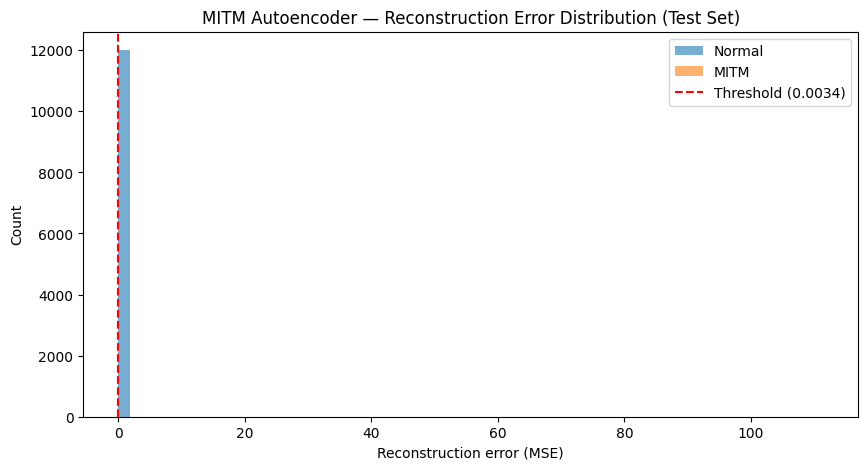

💾 mitm_autoencoder_heldout_metrics.json  |  acc=0.5061  f1=0.0000  auc=nan


/tmp/ipykernel_5655/2879252215.py:32: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at": datetime.utcnow().isoformat(),
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


{'model_name': 'mitm_autoencoder_heldout',
 'trained_at': '2026-04-27T07:59:03.084352',
 'threshold': 0.0033862879212813355,
 'n_samples': 12022,
 'accuracy': 0.5060722009648977,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': nan,
 'pr_auc': 0.0,
 'false_positive_rate': 0.4939277990351023,
 'false_negative_rate': 0.0,
 'confusion_matrix': {'tn': 6084, 'fp': 5938, 'fn': 0, 'tp': 0},
 'classification_report': {'0': {'precision': 1.0,
   'recall': 0.5060722009648977,
   'f1-score': 0.6720424168783828,
   'support': 12022.0},
  '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0},
  'accuracy': 0.5060722009648977,
  'macro avg': {'precision': 0.5,
   'recall': 0.25303610048244884,
   'f1-score': 0.3360212084391914,
   'support': 12022.0},
  'weighted avg': {'precision': 1.0,
   'recall': 0.5060722009648977,
   'f1-score': 0.6720424168783828,
   'support': 12022.0}},
 'dataset': 'IoTID20',
 'split': '30% held-out test'}

In [207]:
# ===============================
# MITM HELD-OUT TEST EVALUATION
# ===============================
# Re-uses the test split created in Section 19.
# Produces a classification report, confusion matrix, AUC,
# and a histogram of reconstruction errors.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_true = mitm_y_test.values
errors = mitm_test_errors
y_pred = (errors > threshold).astype(int)

print(f"Test rows: {len(y_true)}  |  Normal: {int((y_true==0).sum())}  |  MITM: {int((y_true==1).sum())}")
print(classification_report(y_true, y_pred, target_names=["Normal", "MITM"]))
print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_true, errors):.4f}")

# Distribution plot
plt.figure(figsize=(10, 5))
plt.hist(errors[y_true == 0], bins=60, alpha=0.6, label="Normal")
plt.hist(errors[y_true == 1], bins=60, alpha=0.6, label="MITM")
plt.axvline(threshold, linestyle="--", color="red", label=f"Threshold ({threshold:.4f})")
plt.legend()
plt.title("MITM Autoencoder — Reconstruction Error Distribution (Test Set)")
plt.xlabel("Reconstruction error (MSE)")
plt.ylabel("Count")
plt.show()

# Save a separate metrics file for the held-out evaluation
evaluate_and_save(
    "mitm_autoencoder_heldout",
    y_true=y_true, y_prob=errors, y_pred=y_pred,
    threshold=threshold,
    extra={"dataset": "IoTID20", "split": "30% held-out test"},
)


## 21. MITM — Inference & Deployment Test

Smoke tests the saved MITM artifacts on a small batch to confirm they load and score correctly.


In [208]:
import pandas as pd
import numpy as np
import json
import joblib
import tensorflow as tf
import logging

# -------------------------------
# Setup logging
# -------------------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler("inference.log"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger()

# -------------------------------
# Load saved artifacts
# -------------------------------
logger.info("Loading trained artifacts...")

autoencoder = tf.keras.models.load_model("mitm_autoencoder.keras")
scaler = joblib.load("mitm_scaler.pkl")

with open("mitm_config.json", "r") as f:
    config = json.load(f)

threshold = config["threshold"]
feature_columns = config["feature_columns"]

# You can tune this multiplier later
malicious_multiplier = 2.0
malicious_threshold = threshold * malicious_multiplier

logger.info(f"Loaded threshold: {threshold}")
logger.info(f"Loaded malicious threshold: {malicious_threshold}")
logger.info(f"Loaded {len(feature_columns)} feature columns")

# -------------------------------
# Helper: preprocess any file
# -------------------------------
def load_and_prepare_file(file_path: str):
    logger.info(f"Loading file: {file_path}")

    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    drop_cols = [
        "Flow ID",
        "Source IP",
        "Source Port",
        "Destination IP",
        "Destination Port",
        "Timestamp"
    ]

    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    actual_label_column = None
    candidate_label_cols = ["Label", "label", "Cat", "attack_type", "Class", "classification"]
    for col in candidate_label_cols:
        if col in df.columns:
            actual_label_column = col
            break

    if actual_label_column:
        logger.info(f"Identified label column: '{actual_label_column}'")
        df["label_binary"] = (df[actual_label_column].astype(str).str.strip().str.lower() != "benign").astype(int)
        cols_to_drop_for_X = [actual_label_column, "label_binary"]
    else:
        logger.warning("No suitable label column found. Creating a dummy 'label_binary' column (all 0s) and not dropping any original label column for feature extraction.")
        df["label_binary"] = pd.Series(0, index=df.index, name="label_binary")
        cols_to_drop_for_X = ["label_binary"]

    X = df.drop(columns=[c for c in cols_to_drop_for_X if c in df.columns])
    X = X.select_dtypes(include=[np.number])

    # Ensure all feature_columns are present, fill missing with 0
    missing_cols = set(feature_columns) - set(X.columns)
    for c in missing_cols:
        X[c] = 0
    X = X[feature_columns] # exact training column order

    return df, X, actual_label_column # Return original df (with label_binary), prepared features, and the identified label column name

# -------------------------------
# Helper: classify by 3 levels
# -------------------------------
def classify_error(error):
    if error <= threshold:
        return "Normal"
    elif error <= malicious_threshold:
        return "Suspicious"
    else:
        return "Malicious"

# -------------------------------
# Main detection function
# -------------------------------
def detect_anomaly(input_df: pd.DataFrame):
    logger.info("Starting anomaly detection...")

    input_df = input_df.copy()
    # Check if all feature_columns are present in input_df, if not, fill missing with 0
    missing_cols = set(feature_columns) - set(input_df.columns)
    for c in missing_cols:
        input_df[c] = 0
    input_df = input_df[feature_columns]

    logger.info(f"Input shape before scaling: {input_df.shape}")

    X_scaled = scaler.transform(input_df)
    logger.info("Scaling complete")

    reconstructed = autoencoder(X_scaled, training=False).numpy()
    logger.info("Autoencoder prediction complete")

    errors = np.mean(np.square(X_scaled - reconstructed), axis=1)

    predictions = [classify_error(err) for err in errors]

    results = pd.DataFrame({
        "reconstruction_error": errors,
        "normal_threshold": threshold,
        "malicious_threshold": malicious_threshold,
        "prediction": predictions
    })

    logger.info("Detection completed")
    return results

# -------------------------------
# Test any file
# Change this filename whenever you want
# -------------------------------
test_file = "Monday-WorkingHours.pcap_ISCX.csv"

df_test, X_test, identified_label_column = load_and_prepare_file(test_file)

print("Label distribution in selected file:")
if identified_label_column:
    print(df_test[identified_label_column].value_counts())
else:
    print("No original label column found to show distribution. 'label_binary' is all 0s.")

# -------------------------------
# Test random rows
# -------------------------------
sample_random = X_test.sample(10, random_state=42)
result_random = detect_anomaly(sample_random)

print("\nRandom sample results:")
print(result_random)

# -------------------------------
# Test only BENIGN rows
# -------------------------------
df_benign = pd.DataFrame() # Initialize as empty
if identified_label_column:
    df_benign = df_test[df_test[identified_label_column].astype(str).str.strip().str.lower() == "benign"].copy()
else:
    logger.info("Skipping BENIGN-only test as no original label column was identified.")

if not df_benign.empty:
    X_benign = df_benign.drop(columns=[c for c in [identified_label_column, "label_binary"] if c in df_benign.columns])
    X_benign = X_benign.select_dtypes(include=[np.number])
    # Ensure all feature_columns are present, fill missing with 0
    missing_cols = set(feature_columns) - set(X_benign.columns)
    for c in missing_cols:
        X_benign[c] = 0
    X_benign = X_benign[feature_columns]

    benign_sample = X_benign.sample(min(10, len(X_benign)), random_state=42)
    benign_results = detect_anomaly(benign_sample)

    print("\nBenign-only sample results:")
    print(benign_results)

# -------------------------------
# Test only ATTACK rows
# -------------------------------
df_attack = pd.DataFrame() # Initialize as empty
if identified_label_column:
    df_attack = df_test[df_test[identified_label_column].astype(str).str.strip().str.lower() != "benign"].copy()
else:
    logger.info("Skipping ATTACK-only test as no original label column was identified.")

if not df_attack.empty:
    X_attack = df_attack.drop(columns=[c for c in [identified_label_column, "label_binary"] if c in df_attack.columns])
    X_attack = X_attack.select_dtypes(include=[np.number])
    # Ensure all feature_columns are present, fill missing with 0
    missing_cols = set(feature_columns) - set(X_attack.columns)
    for c in missing_cols:
        X_attack[c] = 0
    X_attack = X_attack[feature_columns]

    attack_sample = X_attack.sample(min(10, len(X_attack)), random_state=42)
    attack_results = detect_anomaly(attack_sample)

    print("\nAttack-only sample results:")
    print(attack_results)

    print("\nAttack labels sampled from this file:")
    if identified_label_column:
        print(df_attack[identified_label_column].value_counts())
    else:
        print("No original label column found to print attack labels.")

Label distribution in selected file:
Label
BENIGN    529481
Name: count, dtype: int64

Random sample results:
   reconstruction_error  normal_threshold  malicious_threshold prediction
0              0.797308          0.003386             0.006773  Malicious
1              0.797308          0.003386             0.006773  Malicious
2              0.797308          0.003386             0.006773  Malicious
3              0.797308          0.003386             0.006773  Malicious
4              0.797308          0.003386             0.006773  Malicious
5              0.797308          0.003386             0.006773  Malicious
6              0.797308          0.003386             0.006773  Malicious
7              0.797308          0.003386             0.006773  Malicious
8              0.797308          0.003386             0.006773  Malicious
9              0.797308          0.003386             0.006773  Malicious

Benign-only sample results:
   reconstruction_error  normal_threshold  mali

## Final Notebook Output Checklist

After running this training-only notebook, confirm these files exist in `models/`:

- `rf_model.pkl`
- `iso_model.pkl`
- `feature_columns.pkl`
- `rf_threshold.pkl`
- `iso_threshold.pkl`
- `mitm_autoencoder.keras`
- `mitm_scaler.pkl`
- `mitm_config.json`

This notebook should not start FastAPI, send emails, log live requests, or run dashboard APIs.
